In [30]:
import numpy as np
import os,glob
# Cosmetics:
import matplotlib.pyplot as plt
from typing import Tuple

import seaborn as sns
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

In [6]:
# ATLAS Pixel layers: 
pixelLayers = np.array([(33.5,33.5,0.,400.), (50.5,50.5,0.,400.), (88.5,88.5,0.,400.), (122.5,122.5,0.,400.),(88.5,130.,495.,495.),(88.5,130.,580.,580.),(88.5,130.,650.,650.)],dtype=np.dtype([('Rmin_mm', float),('Rmax_mm', float),('Zmin_mm', float),('Zmax_mm',float)]))
# ATLAS SCT layers: 
sctLayers = np.array([(299.0,299.0,0.,749.),(371.0,371.0,0.,749.),(443.0,443.0,0.,749.),(514.0,514.0,0.,749.),(337.6,560.0,853.8,853.8),(275.0,560.0,934.,934.0),(275.0,560.0,1091.5,1091.5),(275.0,560.0,1299.9,1299.9),(275.0,560.0,1399.7,1399.7),(275.0,560.0,1771.4,1771.4),(337.6,560.0,2115.2,2115.2),(408.0,560.0,2505.0,2505.0),(438.8,560.0,2720.2,2720.2)],dtype=np.dtype([('Rmin_mm', float),('Rmax_mm', float),('Zmin_mm', float),('Zmax_mm',float)]))

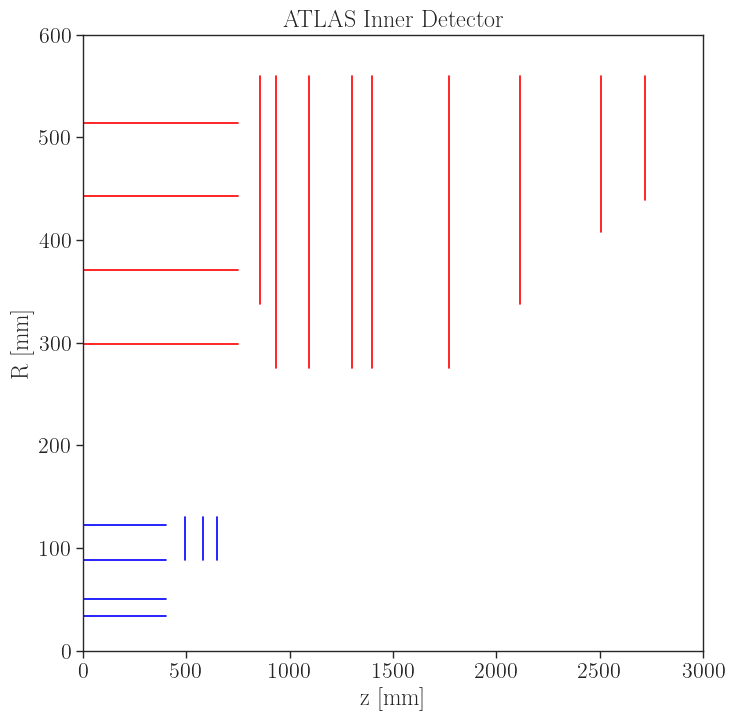

In [4]:
fig = plt.figure(figsize=(8,8))
for layer in pixelLayers:
    plt.plot([layer['Zmin_mm'], layer['Zmax_mm']], [layer['Rmin_mm'], layer['Rmax_mm']], color='blue', label='Pixel')
for layer in sctLayers:
    plt.plot([layer['Zmin_mm'], layer['Zmax_mm']], [layer['Rmin_mm'], layer['Rmax_mm']], color='red', label='SCT')
plt.xlabel('z [mm]')
plt.ylabel('R [mm]')
plt.title('ATLAS Inner Detector')
plt.xlim(0,3000)
plt.ylim(0,600)
# plt.legend()
plt.show()

In [ ]:
def _iter_tracker_segments(layers, tol=1e-9):
    """
    Iterate over the layers and returns the layer boundaries as (rmin, rmax, zmin, zmax) tuples. For layers that are symmetric with respect to the z=0 plane, two segments are returned: one for the positive z side and one for the negative z side.
    """
    for layer in layers:
        rmin = layer['Rmin_mm']
        rmax = layer['Rmax_mm']
        zmin = layer['Zmin_mm']
        zmax = layer['Zmax_mm']

        if np.isclose(rmin, rmax, atol=tol) and np.isclose(zmin, 0.0, atol=tol):
            yield (rmin, rmax, -zmax, zmax)
            continue

        yield (rmin, rmax, zmin, zmax)
        if not np.isclose(zmin, 0.0, atol=tol) or not np.isclose(zmax, 0.0, atol=tol):
            yield (rmin, rmax, -zmax, -zmin)


def cross_layer(R0, z0, vR, vz, segment, tol=1e-9) -> bool:
    """
    Returns True if a track created at (R0, z0) and with velocity (vR, vz) crosses the layer defined by (rmin, rmax, zmin, zmax), and False otherwise.
    """
    rmin, rmax, zmin, zmax = segment

    # Check if is is an horizontal layer    
    if np.isclose(rmin, rmax, atol=tol):
        # A non-zero radial velocity is needed to cross it
        if np.isclose(vR, 0.0, atol=tol):
            return False

        # Compute the time to cross the layer's radius
        # (if it is negative, it means the track does not cross the layer)
        t_cross = (rmin - R0) / vR
        if t_cross <= tol:
            return False

        # Now compute the z coordinate at which the track crosses the layer, and check if it is within the layer's z range
        z_cross = z0 + vz * t_cross
        if (z_cross > zmax + tol) or (z_cross < zmin - tol):
            return False
        else:
            return True

    # Check if is is an horizontal layer   
    elif np.isclose(zmin, zmax, atol=tol):
        # A non-zero longitudinal velocity is needed to cross it
        if np.isclose(vz, 0.0, atol=tol):
            return False

        # Compute the time to cross the layer's radius
        # (if it is negative, it means the track does not cross the layer)
        t_cross = (zmin - z0) / vz
        if t_cross <= tol:
            return False

        # Now compute the radial coordinate at which the track crosses the layer, and check if it is within the layer's R range
        r_cross = R0 + vR * t_cross
        if (r_cross < rmin - tol) or (r_cross > rmax + tol):
            return False
        else:
            return True
    else:
        raise ValueError('Only axis-aligned tracker layers are supported.')


def count_crossed_layers(R0, z0, vR, vz, layers, tol=1e-9):
    """
    Returns the number of layers crossed by a track created at (R0, z0) and with velocity (vR, vz) among the given layers. The layers should be given as a list of (rmin, rmax, zmin, zmax) tuples, or as a structured array with fields 'Rmin_mm', 'Rmax_mm', 'Zmin_mm', 'Zmax_mm'. Only axis-aligned layers are supported.
    """
    ncrossings = 0
    for segment in _iter_tracker_segments(layers, tol=tol):
        cross = cross_layer(R0, z0, vR, vz, segment, tol=tol)
        if cross:
            ncrossings += 1
    return ncrossings


def count_tracker_layer_crossings(R0, z0, vR, vz, tol=1e-9):
    """
    Returns the number of pixel and SCT layers crossed by a track created at (R0, z0) and with velocity (vR, vz). The layers should be given as a list of (rmin, rmax, zmin, zmax) tuples, or as a structured array with fields 'Rmin_mm', 'Rmax_mm', 'Zmin_mm', 'Zmax_mm'. Only axis-aligned layers are supported.
    """
    pixel_hits = count_crossed_layers(R0, z0, vR, vz, pixelLayers, tol=tol)
    sct_hits = count_crossed_layers(R0, z0, vR, vz, sctLayers, tol=tol)
    return {
        'pixel': pixel_hits,
        'sct': sct_hits,
        'total': pixel_hits + sct_hits,
    }

In [37]:
R0, z0 = 100.0, 100.0
vR, vz = 1.0, 0.5
count_tracker_layer_crossings(R0, z0, vR, vz)

{'pixel': 1, 'sct': 4, 'total': 5}

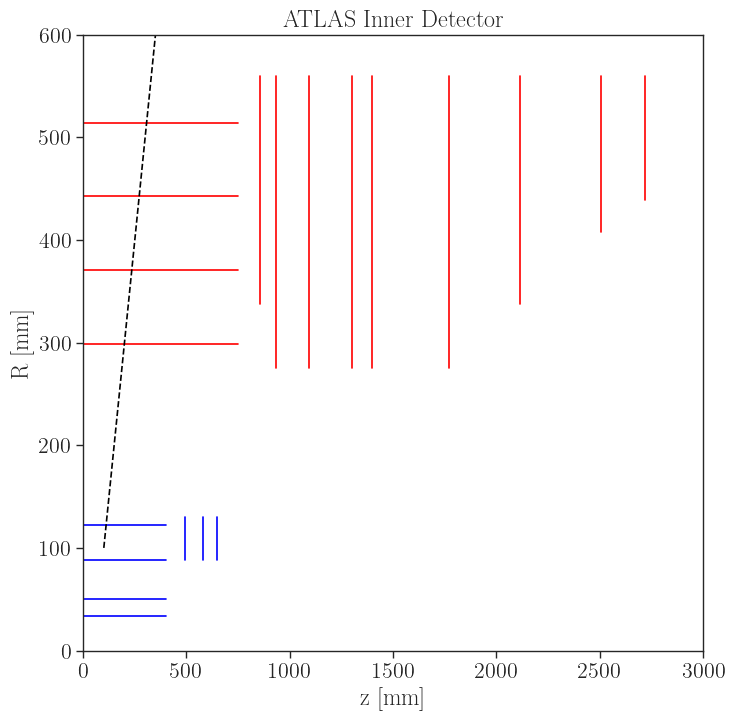

In [38]:
tmax = 1e4
Rf = R0 + vR * tmax
zf = z0 + vz * tmax

fig = plt.figure(figsize=(8,8))
for layer in pixelLayers:
    plt.plot([layer['Zmin_mm'], layer['Zmax_mm']], [layer['Rmin_mm'], layer['Rmax_mm']], color='blue', label='Pixel')
for layer in sctLayers:
    plt.plot([layer['Zmin_mm'], layer['Zmax_mm']], [layer['Rmin_mm'], layer['Rmax_mm']], color='red', label='SCT')
plt.plot([z0, zf], [R0, Rf], color='black', label='Track', linestyle='--')
plt.xlabel('z [mm]')
plt.ylabel('R [mm]')
plt.title('ATLAS Inner Detector')
plt.xlim(0,3000)
plt.ylim(0,600)
# plt.legend()
plt.show()